# 03 -- Isolation by distance

Computes linearized pairwise site-level Fst and regresses against geographic distance.

**Inputs**
- `table_S1.tsv` --> STAGdb metadata for samples included in manuscript
- `mac_ld.gt_matrix.int8.npz` from `convert_vcf_to_npz.py` --> not downsampled, no global MAF filter


**Outputs**
- `apal_ibd.tsv` --> filtered and merged sites for IBD analysis
- `lin_fst_sites.tsv` --> linearized site-level pairwise Fst table
- `ibd_florida.pdf`
- `ibd_greater_antilles.pdf`

---

## Imports and paths

In [1]:
from __future__ import annotations

import itertools
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

sys.path.insert(0, str(Path("../scripts")))

from gt_io import load_cache_npz, write_cache_npz, basic_parse_report

from popgen_utils import (
    build_symmetric_pair_matrix,
    compute_ibd_stats_from_long_df,
    dosage_to_genotype_array,
    fst_mat_to_nm_long,
    fst_pair_with_nloci,
    haversine_km,
    linearized_fst,
    mantel_test,
    order_sites_greedy_nn,
)

import plotly.express as px


In [2]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 150)

In [3]:
PROJECT_DIR = Path("/Users/kidelu001/awi-work/science/projects/apal_popgen/github")
# PROJECT_DIR = Path(/path/to/your/project)

# input
META_TSV  = PROJECT_DIR / "table_S1_metadata.tsv"

DATA_DIR = Path("/Users/kidelu001/awi-work/science/projects/apal_popgen/deriv/manuscript")

NPZ = DATA_DIR / "maf_ld_prev.gt_matrix.int8.npz"

------

## IBD functions

In [4]:
def build_panel(apal_ibd, gt, subregion, site_merge_fn=None, site_merge_map=None):
    """
    Filter to subregion, apply site merges, align to NPZ order,
    deduplicate (one sample per MLG × site), filter by min genets,
    and return a trimmed GenotypeArray.

    Parameters
    ----------
    site_merge_fn  : callable  – e.g. a custom function
    site_merge_map : dict      – e.g. GA_SITE_MERGE_MAP or FL_SITE_MERGE_MAP

    Returns
    -------
    panel       : pd.DataFrame  sample metadata aligned to gta columns
    site_coords : pd.DataFrame  per-site centroid + n_genets
    gta         : allel.GenotypeArray
    """
    panel = apal_ibd[apal_ibd[IBD_COL] == subregion].copy()

    if site_merge_fn is not None:
        panel["site_merged"] = panel[SITE_COL].map(site_merge_fn)
    elif site_merge_map is not None:
        panel["site_merged"] = panel[SITE_COL].map(lambda x: site_merge_map.get(x, x))
    else:
        panel["site_merged"] = panel[SITE_COL]

    # align to NPZ sample order
    npz_lookup = {s: i for i, s in enumerate(gt.sample_ids)}
    panel = panel[panel[ID_COL].isin(npz_lookup)].copy()
    panel["_npz_idx"] = panel[ID_COL].map(npz_lookup)
    panel = panel.sort_values("_npz_idx").reset_index(drop=True)

    # deduplicate: one sample per (MLG, merged site)
    panel = (
        panel
        .drop_duplicates(subset=[MLG_COL, "site_merged"], keep="first")
        .reset_index(drop=True)
    )

    # filter sites by min_genets
    site_n = panel.groupby("site_merged")[MLG_COL].nunique()
    valid  = site_n[site_n >= MIN_GENETS_PER_SITE].index
    panel  = panel[panel["site_merged"].isin(valid)].copy().reset_index(drop=True)

    # site centroids and genet counts
    site_coords = (
        panel.groupby("site_merged")
        .agg(
            lat_median=(LAT_COL, "median"),
            lon_median=(LON_COL, "median"),
            n_genets=(MLG_COL, "nunique"),
        )
        .reset_index()
        .rename(columns={"site_merged": "site"})
    )

    # subset genotype matrix and build GenotypeArray
    G_sub = gt.G[:, panel["_npz_idx"].to_numpy()]
    gta   = dosage_to_genotype_array(G_sub)

    return panel, site_coords, gta


def compute_pairwise_fst(panel, gta):
    """Weir-Cockerham FST for all site pairs. Returns a long DataFrame."""
    sites = sorted(panel["site_merged"].unique())
    rows  = []
    for s1, s2 in itertools.combinations(sites, 2):
        mask1 = (panel["site_merged"] == s1).values
        mask2 = (panel["site_merged"] == s2).values
        fst, n_loci = fst_pair_with_nloci(gta, mask1, mask2)
        rows.append({"site1": s1, "site2": s2, "fst": fst, "n_loci": n_loci})
    return pd.DataFrame(rows)


def build_ibd_df(fst_df, site_coords_ordered, site_region=None):
    """
    Add linearized FST, geographic distance, along-tract distance,
    and optionally a pair_group column for coloring.

    Parameters
    ----------
    site_region : dict, optional
        Mapping of site name → region label (e.g. "Puerto Rico", "USVI").
        When provided, adds a ``pair_group`` column: within-region pairs
        get the region label; cross-region pairs get "A × B".
    """
    df            = fst_df.copy()
    df["linearized_fst"] = df["fst"].apply(linearized_fst)
    coord = site_coords_ordered.set_index("site")[["lat_median", "lon_median", "tract_km"]]

    df["geo_dist_km"] = df.apply(lambda r: haversine_km(
        coord.loc[r["site1"], "lat_median"], coord.loc[r["site1"], "lon_median"],
        coord.loc[r["site2"], "lat_median"], coord.loc[r["site2"], "lon_median"],
    ), axis=1)
    df["along_tract_km"] = df.apply(lambda r: abs(
        coord.loc[r["site1"], "tract_km"] - coord.loc[r["site2"], "tract_km"]
    ), axis=1)

    if site_region is not None:
        def _pair_group(r):
            g1 = site_region.get(r["site1"], "Unknown")
            g2 = site_region.get(r["site2"], "Unknown")
            return g1 if g1 == g2 else f"{g1} × {g2}"
        df["pair_group"] = df.apply(_pair_group, axis=1)

    return df


def plot_ibd(ibd_df, x_col="geo_dist_km", y_col="linearized_fst",
             title="IBD", save_base=None, figsize=(5, 5),
             hue_col=None, palette=None):
    """
    IBD scatter with OLS regression line and annotated statistics.

    Parameters
    ----------
    hue_col : str, optional
        Column in ibd_df to color points by (e.g. ``'pair_group'``).
        Requires build_ibd_df to have been called with ``site_region``.
    palette : dict, optional
        Mapping of hue value → color. Defaults to matplotlib color cycle.
    """
    cols = [x_col, y_col] + ([hue_col] if hue_col else [])
    df   = ibd_df[cols].dropna()
    x, y = df[x_col].values, df[y_col].values

    ols    = stats.linregress(x, y)
    r2     = ols.rvalue ** 2
    istats = compute_ibd_stats_from_long_df(
        ibd_df, x_col=x_col, y_col=y_col, n_perm=N_MANTEL_PERM
    )

    fig, ax = plt.subplots(figsize=figsize)

    if hue_col is not None:
        groups = sorted(df[hue_col].unique())
        if palette is None:
            cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]
            palette = {g: cycle[i % len(cycle)] for i, g in enumerate(groups)}
        for grp, grp_df in df.groupby(hue_col):
            ax.scatter(
                grp_df[x_col], grp_df[y_col],
                s=40, edgecolors="k", linewidths=0.5, alpha=0.8,
                color=palette.get(grp, "steelblue"), label=grp, zorder=3,
            )
        ax.legend(title=hue_col, fontsize=7, title_fontsize=8,
                  loc="upper left", framealpha=0.9)
    else:
        ax.scatter(x, y, s=40, edgecolors="k", linewidths=0.5, alpha=0.8, zorder=3)

    xline = np.linspace(x.min(), x.max(), 200)
    ax.plot(xline, ols.slope * xline + ols.intercept, color="0.4", lw=1)

    label = (
        f"$R^2$ = {r2:.3f}  (p = {istats['ols_p']:.3f})\n"
        f"Mantel r = {istats['mantel_r']:.3f}  (p = {istats['mantel_p']:.3f})\n"
        f"n pairs = {istats['n_pairs']}"
    )
    ax.text(0.97, 0.05, label, transform=ax.transAxes, fontsize=8,
            ha="right", va="bottom",
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="0.8", alpha=0.9))

    ax.set_xlabel("Geographic distance (km)")
    ax.set_ylabel("$F_{ST}$ / (1 \u2212 $F_{ST}$)")
    ax.set_title(title)
    ax.grid(True, alpha=0.25)
    plt.tight_layout()

    if save_base is not None:
        for ext in ("pdf", "eps"):
            fig.savefig(f"{save_base}.{ext}", bbox_inches="tight")
        print(f"Saved \u2192 {save_base}.pdf / .eps")

    plt.show()
    return istats


----
## Filter metadata to IBD sites

In [5]:
meta = pd.read_csv(META_TSV, sep="\t", low_memory=False)

In [6]:
ID_COL          = "affymetrix_id"
SPECIES_COL     = "species"
MLG_COL         = "mlg"
REGION_COL      = "region"
SUBREGION_COL   = "region_sub"
REEF_COL        = "reef"
LAT_COL         = "lat_clean"
LON_COL         = "lon_clean"
NURSERY_COL     = "is_nursery"
 

In [7]:
apal_wild = meta.loc[
    ~meta[NURSERY_COL]
].copy().reset_index(drop=True)

apal_wild.shape

(2632, 25)

In [8]:
apal_wild['subregion_ibd'] = 'Exclude'

florida_regions = ['Florida']
grant_regions = ['Dominican Republic', 'Puerto Rico', 'USVI']

apal_wild.loc[apal_wild[REGION_COL].isin(florida_regions), 'subregion_ibd'] = 'Florida'
apal_wild.loc[apal_wild[REGION_COL].isin(grant_regions), 'subregion_ibd'] = 'GreaterAntilles'

apal_wild['subregion_ibd'].value_counts(dropna=False)


subregion_ibd
Florida            1453
Exclude             608
GreaterAntilles     571
Name: count, dtype: int64

----
## Greater Antilles

In [9]:
grant_df = apal_wild.loc[
    apal_wild["subregion_ibd"] == "GreaterAntilles"
].copy().reset_index(drop=True)

In [10]:
grant_site_counts = (
    grant_df.groupby([SUBREGION_COL, REEF_COL], dropna=False)
    .agg(
        # n_rows=(ID_COL, "size"),
        n_genets=(MLG_COL, lambda s: s.nunique(dropna=True)),
        lat_clean=(LAT_COL, "median"),
        lon_clean=(LON_COL, "median"),
    )
    .reset_index()
    .sort_values(["n_genets", SUBREGION_COL, REEF_COL], ascending=[False, True, True])
    .reset_index(drop=True)
)

grant_site_counts

,region_sub,reef,n_genets,lat_clean,lon_clean
0,Puerto Rico,Gilligan's Reef,29,17.939170,-66.869200
1,Dominican Republic,PuntaCana,28,18.527480,-68.357600
2,USVI,Buck Island,19,17.780760,-64.587480
3,USVI,Rust Op Twist,17,17.782790,-64.792010
4,Dominican Republic,Catalina,16,18.376290,-69.008500
5,Dominican Republic,Minitas,16,18.401240,-68.920900
6,Puerto Rico,Cayo Lajas,15,17.937500,-66.899400
7,Puerto Rico,Cayo Coral HMO5,14,17.937620,-66.890900
8,Puerto Rico,Laurel,14,17.941900,-67.057500
9,Puerto Rico,Penon Moncho Diaz,14,18.472240,-66.478700


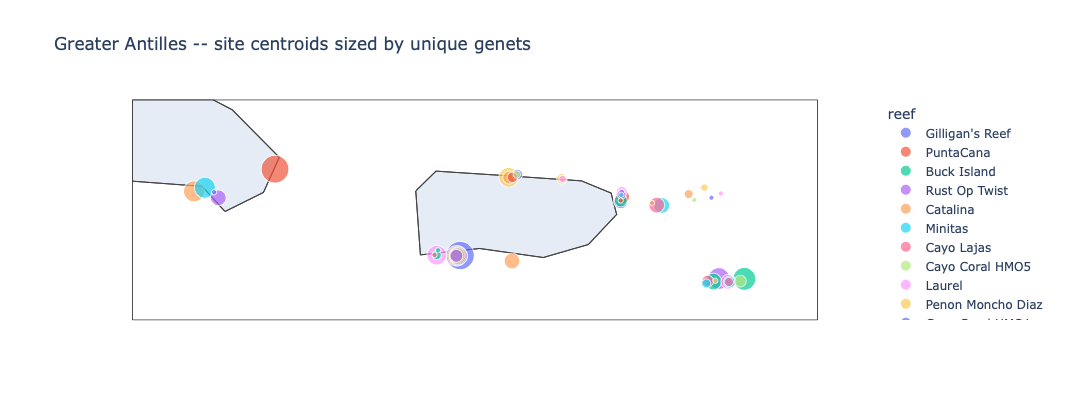

In [11]:
fig = px.scatter_geo(
    grant_site_counts,
    lat=LAT_COL,
    lon=LON_COL,
    color=REEF_COL,
    size="n_genets",
    hover_name=SUBREGION_COL,
    hover_data=[SUBREGION_COL, REEF_COL, "n_genets"],
    title="Greater Antilles -- site centroids sized by unique genets",
)

fig.update_geos(
    scope="world",
    projection_type="natural earth",
    showcountries=True,
    showcoastlines=True,
    lataxis_range=[17.5, 19.0],
    lonaxis_range=[-69.5, -64.0],
)

fig.update_layout(height=400)
fig.show()

In [12]:
grant_df["merged_site"] = grant_df[REEF_COL]

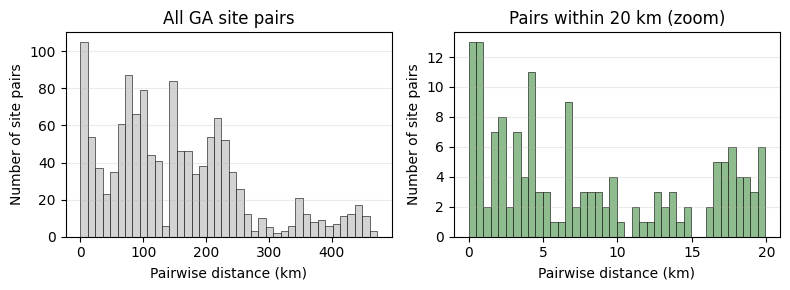

Candidate proximity merges (≤ 10 km, same subregion):


In [13]:
MIN_GENETS_PER_SITE = 5

# explore inter-site distances for proximity-based merges
ga_site_coords_raw = (
    grant_df.groupby(REEF_COL)
    .agg(
        lat_median=(LAT_COL,      "median"),
        lon_median=(LON_COL,      "median"),
        n_genets  =(MLG_COL,      "nunique"),
        subregion =(SUBREGION_COL, "first"),
    )
    .reset_index()
    .rename(columns={REEF_COL: "site"})
)

# pairwise distances (all site pairs)
_sites = ga_site_coords_raw["site"].tolist()
_dist_rows = []
for _i, _s1 in enumerate(_sites):
    for _j, _s2 in enumerate(_sites):
        if _j <= _i:
            continue
        _r1 = ga_site_coords_raw.loc[ga_site_coords_raw["site"] == _s1].iloc[0]
        _r2 = ga_site_coords_raw.loc[ga_site_coords_raw["site"] == _s2].iloc[0]
        _d  = haversine_km(_r1["lat_median"], _r1["lon_median"],
                           _r2["lat_median"], _r2["lon_median"])
        _dist_rows.append({
            "site1":  _s1,           "n1":   int(_r1["n_genets"]),
            "site2":  _s2,           "n2":   int(_r2["n_genets"]),
            "sub1":   _r1["subregion"],       
            "sub2":   _r2["subregion"],      
            "dist_km": _d,
        })

ga_dist_df = pd.DataFrame(_dist_rows)

# distance distribution plots
fig, axes = plt.subplots(1, 2, figsize=(8,3))

axes[0].hist(ga_dist_df["dist_km"], bins=40, edgecolor="k", linewidth=0.4, color="lightgrey")
axes[0].set_xlabel("Pairwise distance (km)")
axes[0].set_ylabel("Number of site pairs")
axes[0].set_title("All GA site pairs")
axes[0].grid(True, alpha=0.25, axis="y")

_close = ga_dist_df[ga_dist_df["dist_km"] <= 20]
axes[1].hist(_close["dist_km"], bins=40, edgecolor="k", linewidth=0.4, color="darkseagreen")
axes[1].set_xlabel("Pairwise distance (km)")
axes[1].set_ylabel("Number of site pairs")
axes[1].set_title("Pairs within 20 km (zoom)")
axes[1].grid(True, alpha=0.25, axis="y")

plt.tight_layout()
plt.show()

# candidate merges: same subregion, close, ≥ 1 site below MIN_GENETS
PROX_THRESH_KM = 10

ga_merge_candidates = ga_dist_df[
    (ga_dist_df["sub1"] == ga_dist_df["sub2"]) &
    (ga_dist_df["dist_km"] <= PROX_THRESH_KM)
].sort_values("dist_km").reset_index(drop=True)

print(f"Candidate proximity merges (≤ {PROX_THRESH_KM} km, same subregion):")


In [14]:
ga_merge_candidates.sort_values(
    ["sub1", "dist_km"], ascending=[True, True]
)[["sub1", "site1", "n1", "site2", "n2", "dist_km"]].reset_index(drop=True)

,sub1,site1,n1,site2,n2,dist_km
0,Dominican Republic,Reef Balls,9,Sombrero,1,5.568270
1,Dominican Republic,Minitas,16,Sombrero,1,8.538613
2,Dominican Republic,Catalina,16,Minitas,16,9.650665
3,Puerto Rico,Laurel,14,San Cristobal,3,0.000000
4,Puerto Rico,Cayo Largo,1,Cayo Largo North,6,0.000000
5,Puerto Rico,Cayo Largo South,4,Lobos,1,0.000000
6,Puerto Rico,Cayo Lajas,15,Coral Uberbs,6,0.000000
7,Puerto Rico,Cayo Largo Norte,7,Cayo Largo North,6,0.011071
8,Puerto Rico,Cayo Largo,1,Cayo Largo Norte,7,0.011071
9,Puerto Rico,Cayo Coral HMO4,10,Cayo Coral HMO5,14,0.117132


In [15]:
# ── build long-format df for merge candidate maps ─────────────────────────────
# one row per (candidate pair × site) so each site inherits its pair's color
_pair_rows = []
for _idx, _row in ga_merge_candidates.iterrows():
    _label = f"{_row['site1']} ↔ {_row['site2']}"
    for _site, _partner in ((_row['site1'], _row['site2']),
                             (_row['site2'], _row['site1'])):
        _info = ga_site_coords_raw.loc[ga_site_coords_raw['site'] == _site].iloc[0]
        _pair_rows.append({
            'site':       _site,
            'subregion':  _row['sub1'],
            'pair_label': _label,
            'partner':    _partner,
            'dist_km':    round(float(_row['dist_km']), 1),
            'n_genets':   int(_info['n_genets']),
            'lat':        _info['lat_median'],
            'lon':        _info['lon_median'],
        })

_merge_plot_df = (
    pd.DataFrame(_pair_rows)
    .drop_duplicates(subset=['site', 'pair_label'])
    .reset_index(drop=True)
)
print(f"{len(_merge_plot_df)} rows | {_merge_plot_df['pair_label'].nunique()} candidate pairs")
_merge_plot_df


202 rows | 101 candidate pairs


,site,subregion,pair_label,partner,dist_km,n_genets,lat,lon
0,Laurel,Puerto Rico,Laurel ↔ San Cristobal,San Cristobal,0.0,14,17.94190,-67.05750
1,San Cristobal,Puerto Rico,Laurel ↔ San Cristobal,Laurel,0.0,3,17.94190,-67.05750
2,Cayo Largo,Puerto Rico,Cayo Largo ↔ Cayo Largo North,Cayo Largo North,0.0,1,18.31447,-65.57920
3,Cayo Largo North,Puerto Rico,Cayo Largo ↔ Cayo Largo North,Cayo Largo,0.0,6,18.31447,-65.57920
4,Cayo Largo South,Puerto Rico,Cayo Largo South ↔ Lobos,Lobos,0.0,4,18.37454,-65.57040
...,...,...,...,...,...,...,...,...
197,Sapphire,USVI,HansLollik2 ↔ Sapphire,HansLollik2,9.7,1,18.33330,-64.84990
198,Ham's Bay,USVI,Ham's Bay ↔ Rust Op Twist,Rust Op Twist,9.8,5,17.76537,-64.88231
199,Rust Op Twist,USVI,Ham's Bay ↔ Rust Op Twist,Ham's Bay,9.8,17,17.78279,-64.79201
200,Llew's Reef 1,USVI,Llew's Reef 1 ↔ Long Reef WAPA,Long Reef WAPA,9.8,5,17.76516,-64.61961


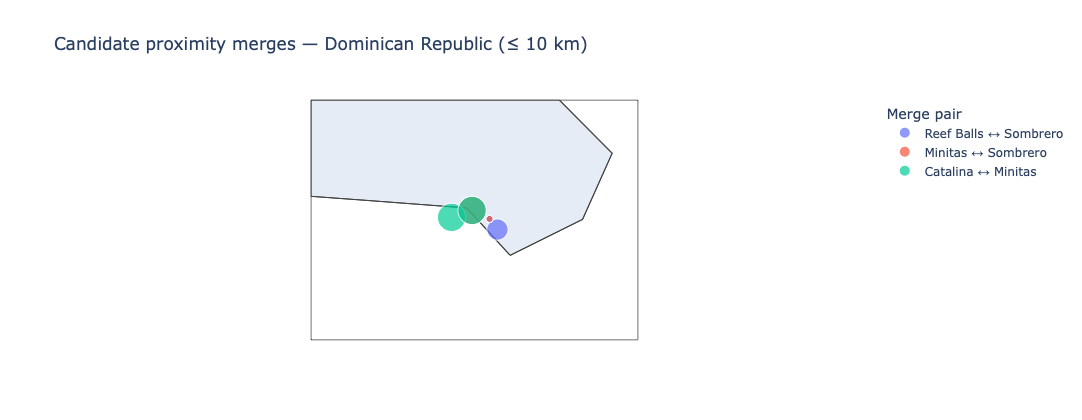

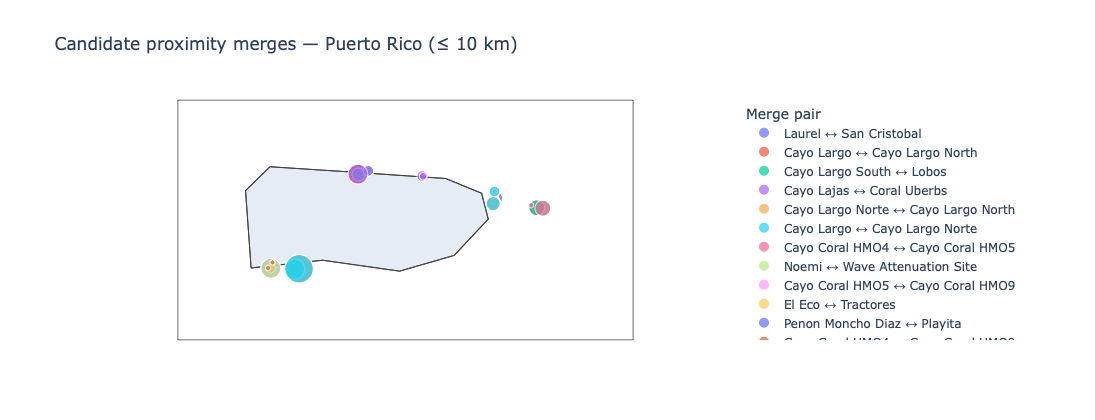

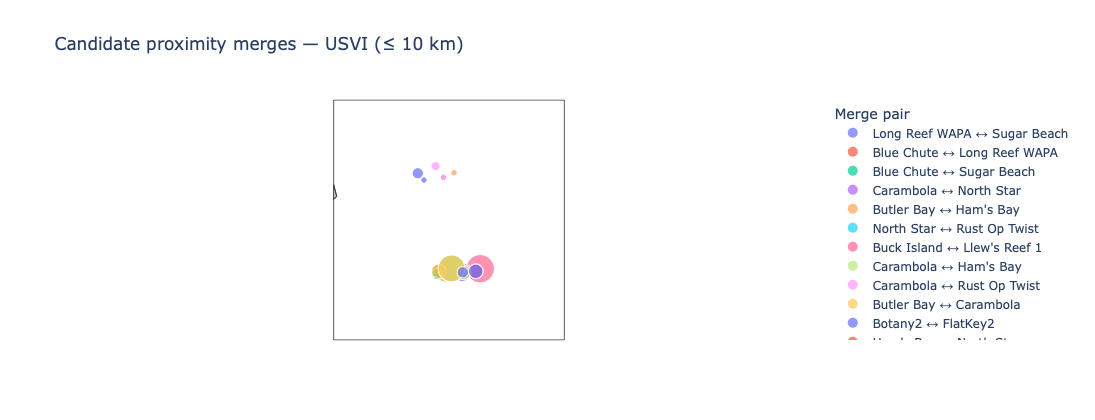

In [16]:
# ── Candidate merge map, one figure per subregion ────────────────────────────
_PAD_LAT, _PAD_LON = 0.4, 0.6   # degrees of padding around the data extent

for _sub in sorted(_merge_plot_df["subregion"].unique()):
    _sub_df = _merge_plot_df[_merge_plot_df["subregion"] == _sub]

    _lat_range = [_sub_df["lat"].min() - _PAD_LAT, _sub_df["lat"].max() + _PAD_LAT]
    _lon_range = [_sub_df["lon"].min() - _PAD_LON, _sub_df["lon"].max() + _PAD_LON]

    fig = px.scatter_geo(
        _sub_df,
        lat="lat",
        lon="lon",
        color="pair_label",
        size="n_genets",
        hover_name="site",
        hover_data={
            "n_genets": True,
            "partner":  True,
            "dist_km":  True,
            "lat":      False,
            "lon":      False,
        },
        labels={
            "pair_label": "Merge pair",
            "n_genets":   "Genets",
            "partner":    "Merge partner",
            "dist_km":    "Distance (km)",
        },
        title=f"Candidate proximity merges — {_sub} (≤ {PROX_THRESH_KM} km)",
    )

    fig.update_geos(
        scope="world",
        projection_type="natural earth",
        showcountries=True,
        showcoastlines=True,
        lataxis_range=_lat_range,
        lonaxis_range=_lon_range,
    )

    fig.update_layout(height=420)
    fig.show()

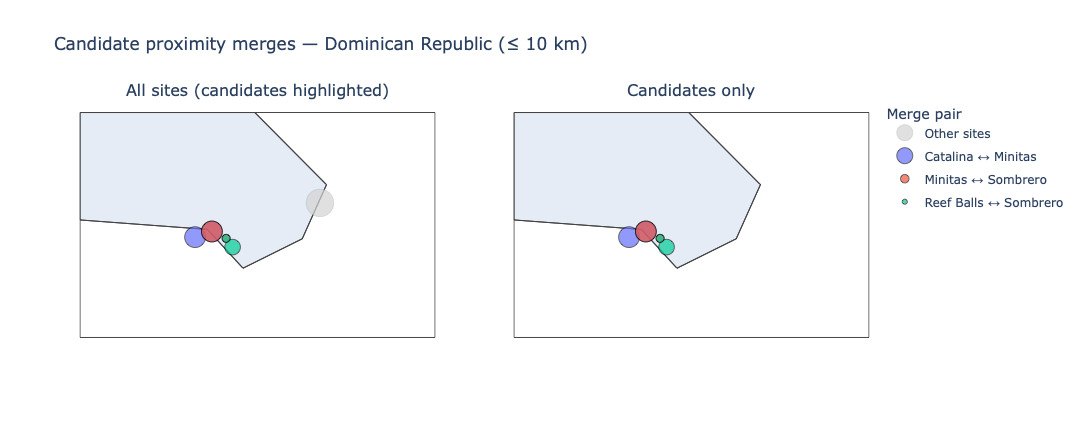

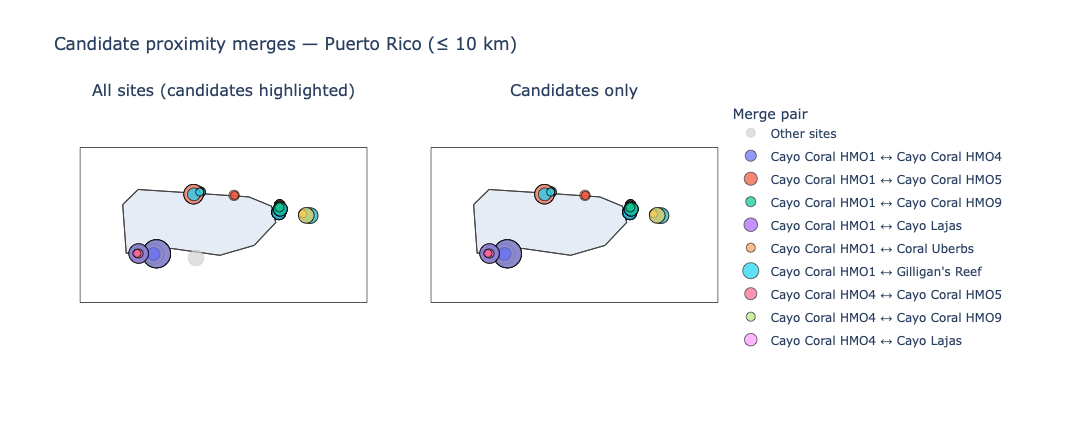

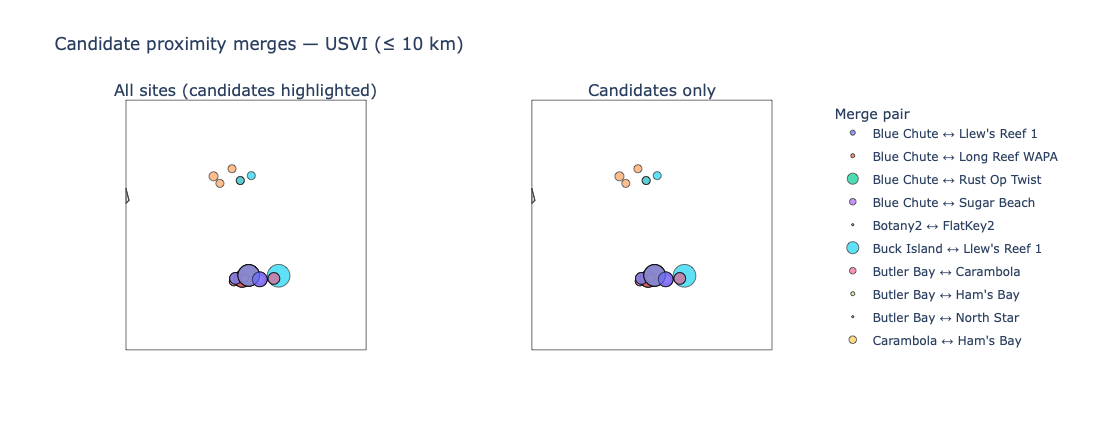

In [17]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go

_PAD_LAT, _PAD_LON = 0.4, 0.6

# consistent size scaling across all panels (same reference as the earlier overview map)
_max_genets = ga_site_coords_raw["n_genets"].max()
_sizeref    = 2 * _max_genets / (28 ** 2)   # ~28 px max diameter

for _sub in sorted(_merge_plot_df["subregion"].unique()):
    _cand_sub  = _merge_plot_df[_merge_plot_df["subregion"] == _sub]
    _all_sub   = ga_site_coords_raw[ga_site_coords_raw["subregion"] == _sub]
    _cand_sites = set(_cand_sub["site"])
    _non_cand   = _all_sub[~_all_sub["site"].isin(_cand_sites)]

    # bounds from all subregion sites (not just candidates)
    _lat_range = [_all_sub["lat_median"].min() - _PAD_LAT,
                  _all_sub["lat_median"].max() + _PAD_LAT]
    _lon_range = [_all_sub["lon_median"].min() - _PAD_LON,
                  _all_sub["lon_median"].max() + _PAD_LON]

    # fixed color map so left and right panels are identical
    _pairs      = sorted(_cand_sub["pair_label"].unique())
    _clr_cycle  = px.colors.qualitative.Plotly
    _pair_color = {p: _clr_cycle[i % len(_clr_cycle)] for i, p in enumerate(_pairs)}

    _geo_cfg = dict(
        scope="world",
        projection_type="natural earth",
        showcountries=True,
        showcoastlines=True,
        lataxis_range=_lat_range,
        lonaxis_range=_lon_range,
    )

    fig = make_subplots(
        rows=1, cols=2,
        specs=[[{"type": "geo"}, {"type": "geo"}]],
        subplot_titles=["All sites (candidates highlighted)", "Candidates only"],
    )

    # ── left panel: grey background sites ──────────────────────────────────────
    if len(_non_cand):
        fig.add_trace(go.Scattergeo(
            lat=_non_cand["lat_median"],
            lon=_non_cand["lon_median"],
            mode="markers",
            marker=dict(
                size=_non_cand["n_genets"],
                sizemode="area", sizeref=_sizeref, sizemin=4,
                color="lightgrey",
                line=dict(width=0.5, color="darkgrey"),
            ),
            text=_non_cand["site"],
            customdata=_non_cand["n_genets"].values,
            hovertemplate="<b>%{text}</b><br>Genets: %{customdata}<extra>other site</extra>",
            name="Other sites",
            legendgroup="other",
            showlegend=True,
        ), row=1, col=1)

    # ── shared helper: one trace per pair, for a given geo panel ───────────────
    def _pair_traces(col, show_legend):
        for _pair in _pairs:
            _pdf = _cand_sub[_cand_sub["pair_label"] == _pair]
            fig.add_trace(go.Scattergeo(
                lat=_pdf["lat"],
                lon=_pdf["lon"],
                mode="markers",
                marker=dict(
                    size=_pdf["n_genets"],
                    sizemode="area", sizeref=_sizeref, sizemin=4,
                    color=_pair_color[_pair],
                    line=dict(width=0.8, color="black"),
                ),
                text=_pdf["site"],
                customdata=_pdf[["n_genets", "partner", "dist_km"]].values,
                hovertemplate=(
                    "<b>%{text}</b><br>"
                    "Genets: %{customdata[0]}<br>"
                    "Merge partner: %{customdata[1]}<br>"
                    "Distance: %{customdata[2]} km"
                    "<extra></extra>"
                ),
                name=_pair,
                legendgroup=_pair,
                showlegend=show_legend,
            ), row=1, col=col)

    _pair_traces(col=1, show_legend=True)   # left: show in legend
    _pair_traces(col=2, show_legend=False)  # right: reuse legend entries

    fig.update_layout(
        geo=_geo_cfg,
        geo2=_geo_cfg,
        title_text=f"Candidate proximity merges — {_sub} (≤ {PROX_THRESH_KM} km)",
        height=430,
        width=980,
        legend=dict(title="Merge pair", tracegroupgap=4),
    )

    fig.show()

In [18]:
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform

# ── build a distance matrix over all GA sites ──────────────────────────────
_site_list = ga_site_coords_raw["site"].tolist()
_n         = len(_site_list)
_dist_mat  = np.zeros((_n, _n))

for _i in range(_n):
    for _j in range(_i + 1, _n):
        _r1, _r2 = ga_site_coords_raw.iloc[_i], ga_site_coords_raw.iloc[_j]
        _d = haversine_km(_r1["lat_median"], _r1["lon_median"],
                          _r2["lat_median"], _r2["lon_median"])
        _dist_mat[_i, _j] = _dist_mat[_j, _i] = _d

# ── complete-linkage clustering: threshold = PROX_THRESH_KM ────────────────
PROX_THRESH_KM = 10

_Z       = linkage(squareform(_dist_mat), method="complete")
_labels  = fcluster(_Z, t=PROX_THRESH_KM, criterion="distance")

ga_site_coords_raw["prox_cluster"] = _labels

# ── build a proximity merge map from clusters that have > 1 site ───────────
_cluster_sizes = ga_site_coords_raw.groupby("prox_cluster")["site"].count()
_multi_clusters = _cluster_sizes[_cluster_sizes > 1].index

GA_PROX_MERGE_MAP = {}
for _cl in _multi_clusters:
    _members = ga_site_coords_raw.loc[
        ga_site_coords_raw["prox_cluster"] == _cl, "site"
    ].tolist()
    # canonical name = member with the most genets
    _canonical = ga_site_coords_raw.loc[
        ga_site_coords_raw["site"].isin(_members)
    ].sort_values("n_genets", ascending=False).iloc[0]["site"]
    for _s in _members:
        GA_PROX_MERGE_MAP[_s] = _canonical

print(f"{len(_multi_clusters)} proximity clusters → {len(GA_PROX_MERGE_MAP)} sites remapped")
GA_PROX_MERGE_MAP

14 proximity clusters → 48 sites remapped


{'Reef Balls': 'Reef Balls',
 'Sombrero': 'Reef Balls',
 'Catalina': 'Catalina',
 'Minitas': 'Catalina',
 'Dominos East': 'Dominos East',
 'Waimea': 'Dominos East',
 'El Eco': 'Penon Moncho Diaz',
 'Los Tubos': 'Penon Moncho Diaz',
 'Penon Moncho Diaz': 'Penon Moncho Diaz',
 'Playita': 'Penon Moncho Diaz',
 'Tractores': 'Penon Moncho Diaz',
 'Cayo Coral HMO1': "Gilligan's Reef",
 'Cayo Coral HMO4': "Gilligan's Reef",
 'Cayo Coral HMO5': "Gilligan's Reef",
 'Cayo Coral HMO9': "Gilligan's Reef",
 'Cayo Lajas': "Gilligan's Reef",
 'Coral Uberbs': "Gilligan's Reef",
 "Gilligan's Reef": "Gilligan's Reef",
 'La Parguera': 'Laurel',
 'Laurel': 'Laurel',
 'San Cristobal': 'Laurel',
 'San Cristobal Forereef': 'Laurel',
 'Cayo Largo': 'Cayo Largo Norte',
 'Cayo Largo Norte': 'Cayo Largo Norte',
 'Cayo Largo North': 'Cayo Largo Norte',
 'Cayo Largo South': 'Cayo Largo Norte',
 'Cayo Largo Sur': 'Cayo Largo Norte',
 'Lobos': 'Cayo Largo Norte',
 'Noemi': 'Cayo Largo Norte',
 'Palomino (Sand Slide 

# Previous code continues below

In [74]:
# Greater Antilles

GA_SITE_MERGE_MAP = {
    # Dominican Republic
    "Minitas":  "DR_Minitas_Catalina",
    "Catalina": "DR_Minitas_Catalina",

    # Puerto Rico: Laurel / San Cristobal cluster
    "Laurel":                  "PR_Laurel_SanCristobal",
    "San Cristobal":           "PR_Laurel_SanCristobal",
    "San Cristobal Forereef":  "PR_Laurel_SanCristobal",

    # Puerto Rico: Cayo Largo / Palomino cluster
    "Cayo Largo Norte":       "PR_CayoLargo_Palomino",
    "Cayo Largo North":       "PR_CayoLargo_Palomino",
    "Cayo Largo Sur":         "PR_CayoLargo_Palomino",
    "Cayo Largo South":       "PR_CayoLargo_Palomino",
    "Wave Attenuation Site":  "PR_CayoLargo_Palomino",
    "Lobos":                  "PR_CayoLargo_Palomino",
    "Palomino (Sand Slide )": "PR_CayoLargo_Palomino",

    # Puerto Rico: individual consolidated sites
    "Gilligan's Reef":  "PR_Gilligans",
    "Cayo Lajas":       "PR_CayoLajas",
    "Coral Uberbs":     "PR_CayoCoral_Uberbs",
    "Cayo Coral HMO1":  "PR_CayoCoral_Uberbs",
    "Cayo Coral HMO4":  "PR_CayoCoral_Uberbs",
    "Cayo Coral HMO5":  "PR_CayoCoral_Uberbs",
    "Cayo Coral HMO9":  "PR_CayoCoral_Uberbs",
}

In [75]:
ga_panel, ga_sites, ga_gta = build_panel(
    apal_ibd, gt,
    subregion="GreaterAntilles",
    site_merge_map=GA_PROX_MERGE_MAP,
)

print(f"{ga_panel['site_merged'].nunique()} sites | {ga_panel[MLG_COL].nunique()} genets")
ga_sites.sort_values("n_genets", ascending=False)


In [ ]:
ga_fst_df = compute_pairwise_fst(ga_panel, ga_gta)
print(f"{len(ga_fst_df)} site pairs | FST range: "
      f"{ga_fst_df['fst'].min():.4f} \u2013 {ga_fst_df['fst'].max():.4f}")
ga_fst_df.head()


In [78]:
ga_sites_ordered = order_sites_greedy_nn(ga_sites)

# region label per merged site (Dominican Republic / Puerto Rico / USVI)
# used for coloring site pairs in the IBD scatter
ga_site_region = (
    ga_panel.groupby("site_merged")[REGION_COL]
    .first()
    .to_dict()
)

ga_ibd_df = build_ibd_df(ga_fst_df, ga_sites_ordered, site_region=ga_site_region)
ga_ibd_df.head()


In [ ]:
# ── GA tract ordering visualization ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# left: sites positioned along the tract (tract_km vs longitude)
ax = axes[0]
ax.plot(ga_sites_ordered["tract_km"], ga_sites_ordered["lon_median"],
        "o-", color="steelblue", ms=6, lw=1)
for _, _row in ga_sites_ordered.iterrows():
    ax.annotate(
        _row["site"],
        (_row["tract_km"], _row["lon_median"]),
        fontsize=6, xytext=(4, 0), textcoords="offset points",
    )
ax.set_xlabel("Along-tract distance (km)")
ax.set_ylabel("Longitude")
ax.set_title("GA sites in greedy-NN tract order")
ax.grid(True, alpha=0.25)

# right: nearest-neighbor step distances
_steps = ga_sites_ordered["tract_km"].diff().dropna()
ax2 = axes[1]
ax2.bar(range(len(_steps)), _steps.values, edgecolor="k", linewidth=0.4, color="steelblue")
ax2.set_xticks(range(len(_steps)))
ax2.set_xticklabels(
    [f"{ga_sites_ordered.iloc[i]['site'][:8]}" for i in range(1, len(ga_sites_ordered))],
    rotation=45, ha="right", fontsize=6,
)
ax2.set_ylabel("Step distance (km)")
ax2.set_title("Nearest-neighbor step distances (GA)")
ax2.grid(True, alpha=0.25, axis="y")

plt.tight_layout()
plt.show()

ga_sites_ordered[["site", "tract_km", "n_genets"]]


In [77]:
ga_stats = plot_ibd(
    ga_ibd_df,
    x_col="geo_dist_km",
    title="IBD \u2014 Greater Antilles",
    hue_col="pair_group",
    save_base=None,
)
ga_stats


In [12]:
ID_COL   = "affymetrix_id"
MLG_COL  = "mlg"
SITE_COL = "reef"
LAT_COL  = "lat_clean"
LON_COL  = "lon_clean"
IBD_COL  = "subregion_ibd"

MIN_GENETS_PER_SITE = 5
N_MANTEL_PERM       = 10_000

In [53]:
apal_ibd = apal_wild.copy()
gt = load_cache_npz(str(NPZ))

print(f"Metadata : {len(apal_ibd):,} samples")
print(f"NPZ      : {gt.G.shape[0]:,} SNPs × {gt.G.shape[1]:,} samples")

apal_ibd[IBD_COL].value_counts()

Metadata : 2,632 samples
NPZ      : 3,535 SNPs × 976 samples


subregion_ibd
Florida            1453
Exclude             608
GreaterAntilles     571
Name: count, dtype: int64

---
## Florida panel

In [ ]:
# ── Florida site merge map ────────────────────────────────────────────────────
# Maps raw reef names from the metadata → canonical site labels.
# Names not present in this dict pass through unchanged (original reef name kept).
#
# Run the sanity check below first to see what names are in your data,
# then fill in / adjust as needed before running build_panel.

FL_SITE_MERGE_MAP = {
    # Sand Key
    "Sand Key":           "Sand Key",
    # Sand Island
    "Sand Island":        "Sand Island",
    "SI3":                "Sand Island",
    # Sambo Reef
    "Sambo":              "Sambo",
    # Elbow Reef
    "Elbow":              "Elbow",
    "EL2":                "Elbow",
    # Looe Key
    "Looe":               "Looe",
    # Biscayne Bay
    "Biscayne":           "Biscayne",
    # Conch Reef
    "Conch":              "Conch",
    "CRF":                "Conch",
    # Fowey Rocks
    "Fowey":              "Fowey",
    # French Reef
    "French":             "French Reef",
    "FR2":                "French Reef",
    # Grecian Rocks
    "Grecian":            "Grecian Rocks",
    "GR1":                "Grecian Rocks",
    # Horseshoe Reef
    "Horseshoe":          "Horseshoe",
    # Brewster Reef
    "Brew":               "Brewster",
    # Marker 3
    "Marker3":            "Marker3",
    "Marker 3":           "Marker3",
    # Ball Buoy
    "Ball Buoy":          "Ball Buoy",
    "Ball Paul":          "Ball Buoy",
    # Carysfort Reef
    "Carysfort":          "Carysfort",
    "CF2":                "Carysfort",
    # Molasses Reef
    "Molasses":           "Molasses",
    "ML3":                "Molasses",
    # Snapper Ledge
    "Snapledge":          "Snapper Ledge",
    "Snapper Ledge":      "Snapper Ledge",
    # Dry Rocks
    "KL4":                "Dry Rocks",
    "Dry Rocks":          "Dry Rocks",
    # Triple A
    "Triple A":           "Triple A",
    # Watson
    "Watson":             "Watson",
    # Turtle Rocks
    "Trtlrks":            "Turtle Rocks",
    "Turtle Rocks":       "Turtle Rocks",
    # Mote Marine
    "Mote":               "Mote",
}

# Sanity check: show any Florida reef names not covered by the map above
_fl_raw = apal_ibd.loc[apal_ibd[IBD_COL] == "Florida", SITE_COL].dropna().unique()
_unmapped = sorted(s for s in _fl_raw if s not in FL_SITE_MERGE_MAP)
if _unmapped:
    print(f"\u26a0  {len(_unmapped)} unmapped Florida reef name(s) — will keep original label:")
    for _s in _unmapped:
        print(f"   {repr(_s)}")
else:
    print("\u2713 All Florida reef names are covered by FL_SITE_MERGE_MAP.")


In [54]:
fl_panel, fl_sites, fl_gta = build_panel(
    apal_ibd, gt,
    subregion="Florida",
    site_merge_map=FL_SITE_MERGE_MAP,
)

print(f"{fl_panel['site_merged'].nunique()} sites | {fl_panel[MLG_COL].nunique()} genets")
fl_sites.sort_values("lon_median")


In [55]:
fl_fst_df = compute_pairwise_fst(fl_panel, fl_gta)
print(f"{len(fl_fst_df)} site pairs | FST range: "
      f"{fl_fst_df['fst'].min():.4f} – {fl_fst_df['fst'].max():.4f}")
fl_fst_df.head()

105 site pairs | FST range: -0.0077 – 0.0594


,site1,site2,fst,n_loci
0,Ball Buoy,Broward County,0.016190,3314
1,Ball Buoy,Carysfort,0.023422,3459
2,Ball Buoy,Conch,0.030005,3366
3,Ball Buoy,Dry Rocks,0.023224,3460
4,Ball Buoy,Elbow,0.017985,3439


In [56]:
fl_sites_ordered = order_sites_greedy_nn(fl_sites)

# region_sub label per merged site (e.g. 'Upper Keys', 'Lower Keys', etc.)
# used for coloring site pairs in the IBD scatter
fl_site_region = (
    fl_panel.groupby("site_merged")[SUBREGION_COL]
    .first()
    .to_dict()
)

fl_ibd_df = build_ibd_df(fl_fst_df, fl_sites_ordered, site_region=fl_site_region)
fl_ibd_df.head()


In [ ]:
# ── FL tract ordering visualization ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# left: sites along the tract
ax = axes[0]
ax.plot(fl_sites_ordered["tract_km"], fl_sites_ordered["lon_median"],
        "o-", color="coral", ms=6, lw=1)
for _, _row in fl_sites_ordered.iterrows():
    ax.annotate(
        _row["site"],
        (_row["tract_km"], _row["lon_median"]),
        fontsize=6, xytext=(4, 0), textcoords="offset points",
    )
ax.set_xlabel("Along-tract distance (km)")
ax.set_ylabel("Longitude")
ax.set_title("FL sites in greedy-NN tract order")
ax.grid(True, alpha=0.25)

# right: nearest-neighbor step distances
_steps = fl_sites_ordered["tract_km"].diff().dropna()
ax2 = axes[1]
ax2.bar(range(len(_steps)), _steps.values, edgecolor="k", linewidth=0.4, color="coral")
ax2.set_xticks(range(len(_steps)))
ax2.set_xticklabels(
    [f"{fl_sites_ordered.iloc[i]['site'][:8]}" for i in range(1, len(fl_sites_ordered))],
    rotation=45, ha="right", fontsize=6,
)
ax2.set_ylabel("Step distance (km)")
ax2.set_title("Nearest-neighbor step distances (FL)")
ax2.grid(True, alpha=0.25, axis="y")

plt.tight_layout()
plt.show()

fl_sites_ordered[["site", "tract_km", "n_genets"]]


In [58]:
fl_stats = plot_ibd(
    fl_ibd_df,
    x_col="geo_dist_km",
    title="IBD \u2014 Florida",
    hue_col="pair_group",
    save_base=None,
)
fl_stats
